# Análisis exploratorio de datos — Fraude

## Objetivo

El enunciado no pide detectar fraude: pide **maximizar la ganancia**. Cada transacción legítima aprobada
rinde el 25% de su monto y cada fraude aprobado pierde el 100%. Por eso cada hallazgo se juzga por cuánto
ayuda a ganar dinero, no por cuánto fraude detecta.

Esta notebook no elige variables ni entrena modelos: abre el archivo y mira qué hay.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

from fraud_detection.constants import (
    AMOUNT,
    CATEGORICAL_COLUMNS,
    GAIN_RATE,
    NOISE_COLUMNS,
    NUMERIC_COLUMNS,
    N_SPLITS,
    TARGET,
    TEST_START,
)
from fraud_detection.dataset import (
    load_transactions,
    normalize_text,
    split_development,
    validate_transactions,
)
from fraud_detection.diagnostics import column_profile, iqr_report, rate_table, summarize_segments
from fraud_detection.evaluation import (
    approve_all,
    expected_gain,
    gain_by_policy,
    max_gain,
    optimal_probability_threshold,
    sweep_gain,
)
from fraud_detection.modeling import temporal_folds
from fraud_detection.plots import (
    PALETTE,
    plot_class_distribution,
    plot_gain_curve,
    plot_rate_table,
    plot_temporal_folds,
)

df = load_transactions()
dias_del_extracto = df.fecha.dt.normalize()
print(
    f"{len(df):,} transacciones | {df.shape[1]} columnas | {dias_del_extracto.nunique()} días, "
    f"del {df.fecha.min():%d/%m/%Y} al {df.fecha.max():%d/%m/%Y}"
)
display(column_profile(df)[["tipo", "valores_distintos"]].assign(ejemplo=df.iloc[0].astype(str)))

150,000 transacciones | 19 columnas | 45 días, del 08/03/2020 al 21/04/2020


,tipo,valores_distintos,ejemplo
a,int64,4,4
b,float64,7672,0.6812
c,float64,135090,50084.12
d,float64,51,50.0
e,float64,43208,0.0
f,float64,1338,20.0
g,str,51,AR
h,int64,59,1
j,str,8324,cat_d26ab52
k,float64,150000,0.3654752356846202


### Qué trae el dataset, y qué no

El extracto tiene **150.000 transacciones de 45 días**, del 08/03/2020 al 21/04/2020.

Salvo `fecha`, `monto`, `score` y `fraude`, los nombres son letras sueltas, de `a` a `p` y sin `i`.
**No hay diccionario de datos**, así que las columnas anónimas se analizan por cómo se comportan, no por
lo que suponemos que miden.

Lo que sí se lee a primera vista: `g` trae códigos de dos letras que parecen países, `o` y `p` toman `Y` y
`N`, `n` es binaria, `score` es un entero y `j` tiene muchísimos valores `cat_*`. Y lo que **no** está:
moneda, identificador de usuario y la decisión que tomó el sistema vigente.

De ahí salen cuatro supuestos que conviene declarar antes de analizar nada:

| Supuesto | Estado | Qué pasa si es falso |
|---|---|---|
| `monto` está en una unidad monetaria común entre países | Sin confirmar: no hay columna de moneda | Las sumas globales de ganancia dejan de ser válidas: habría que convertir antes de optimizar |
| `g` es el país | Sugerido por los códigos de dos letras | Las comparaciones por país quedan como hipótesis |
| `score` está disponible al momento de decidir el pago | **Se evalúa en la sección 5** | Sería fuga de información y no puede usarse como predictor |
| Las etiquetas se confirman sin demora relevante | **Se evalúa en parte en la sección 1**: se puede ver si las del extracto están completas, no cuánto tardan en producción | Los folds entrenarían con días que en producción todavía no tienen etiqueta, y los resultados quedarían optimistas |

Los dos últimos se evalúan con estos datos, el último solo en parte. Los dos primeros requieren el
diccionario y quedan abiertos; se retoman en las conclusiones.

## 1. Cómo se mide: reserva, folds y demora de etiquetas

Antes de mirar los datos, fijar cómo se va a medir todo el trabajo. Las tres decisiones responden a la
misma pregunta: **¿qué va a tener disponible el modelo en producción?** Y los errores esenciales —una
etiqueta inválida o un monto no positivo— **detienen la ejecución** en lugar de corregirse en silencio.

**Por qué reservar por fecha y no al azar.** En producción el modelo siempre predice sobre transacciones
posteriores a las que vio al entrenar; partir al azar mezclaría pasado y futuro. Por eso el corte es una
fecha: `TEST_START`, el 13 de abril de 2020.

**Con qué criterio se eligió esa fecha:** que deje afuera entre el 20 y el 25% de las filas, y que caiga
en lunes, para que desarrollo termine en domingo y los bloques de validación coincidan con semanas
calendario. Desde ese lunes hasta el final del extracto quedan 9 días; un test de exactamente 7 obligaría
a cortar un miércoles. La celda siguiente muestra cuántas filas deja cada opción.

In [2]:
clean = normalize_text(df)

# Detenerse ante errores esenciales, en lugar de eliminarlos silenciosamente.
validate_transactions(clean)

numeric_columns = NUMERIC_COLUMNS
print("Categóricas:", CATEGORICAL_COLUMNS, "| Numéricas:", numeric_columns)

Categóricas: ['a', 'g', 'j', 'o', 'p'] | Numéricas: ['b', 'c', 'd', 'e', 'f', 'h', 'k', 'l', 'm', 'monto', 'score']


In [3]:
development, test = split_development(clean)
assert len(development) + len(test) == len(clean)
print(
    f"Desarrollo: {len(development):,} filas, "
    f"{development.fecha.dt.normalize().nunique()} días "
    f"({development.fecha.min():%d/%m} a {development.fecha.max():%d/%m})"
)
print(
    f"Reservado:  {len(test):,} filas, {test.fecha.dt.normalize().nunique()} días "
    f"({test.fecha.min():%d/%m} a {test.fecha.max():%d/%m}), "
    f"{100 * len(test) / len(clean):.1f}% de las filas"
)
corte_de_7_dias = TEST_START + pd.Timedelta(days=2)
con_7_dias = clean.loc[clean.fecha.ge(corte_de_7_dias)]
print(
    f"Con 7 días (cortando el {corte_de_7_dias:%d/%m}): {len(con_7_dias):,} filas, "
    f"{100 * len(con_7_dias) / len(clean):.1f}% de las filas"
)

Desarrollo: 114,506 filas, 36 días (08/03 a 12/04)
Reservado:  35,494 filas, 9 días (13/04 a 21/04), 23.7% de las filas
Con 7 días (cortando el 15/04): 28,986 filas, 19.3% de las filas


### ¿Las etiquetas del extracto están completas?

Si un fraude tarda en confirmarse y el extracto se generó poco después de la última transacción, las
transacciones más recientes aparecerían como legítimas solo porque su fraude todavía no se detectó. El
síntoma sería visible en la tasa diaria de fraude: caería de forma sostenida en los últimos días, y
cuanto más cerca del final, más bajo.

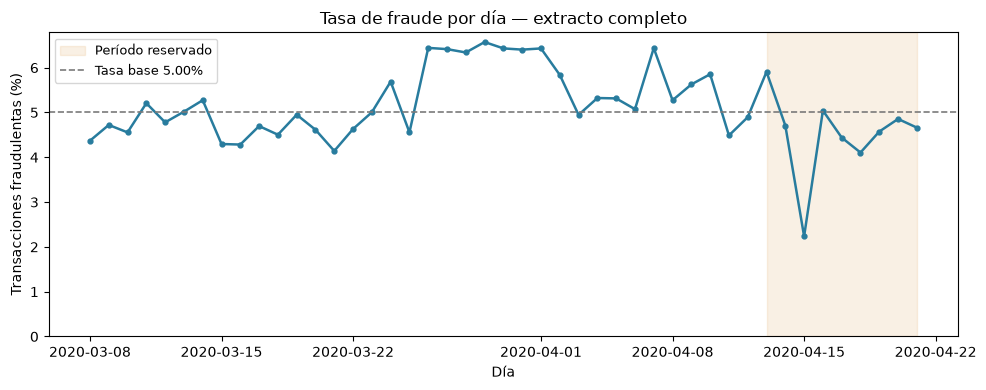


Últimos 3 días del extracto: 4.70% | los 42 anteriores: 5.14%
Últimos 5 días de desarrollo: 5.23% | los 31 anteriores: 5.27%
Día de menor tasa: 15/04 (2.24%)
Período reservado: 4.43% de fraude | desarrollo: 5.18%


In [4]:
# Chequeo de integridad de etiquetas: es la única vez que se mira el período
# reservado y no decide nada del modelado.
diaria = (
    clean.assign(dia=clean.fecha.dt.normalize())
    .groupby("dia")
    .agg(transacciones=(TARGET, "size"), fraude_pct=(TARGET, "mean"))
)
diaria["fraude_pct"] *= 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(diaria.index, diaria.fraude_pct, marker="o", markersize=3.5, color="#287C9E", linewidth=1.8)
ax.axvspan(TEST_START, diaria.index.max(), color="#D38B28", alpha=0.12, label="Período reservado")
ax.axhline(
    clean[TARGET].mean() * 100,
    color="#7A7A7A",
    linestyle="--",
    linewidth=1.2,
    label=f"Tasa base {clean[TARGET].mean():.2%}",
)
ax.set(
    title="Tasa de fraude por día — extracto completo",
    xlabel="Día",
    ylabel="Transacciones fraudulentas (%)",
    ylim=(0, None),
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(
    f"\nÚltimos 3 días del extracto: {diaria.fraude_pct.tail(3).mean():.2f}% | "
    f"los 42 anteriores: {diaria.fraude_pct.head(-3).mean():.2f}%"
)
print(
    f"Últimos 5 días de desarrollo: {diaria.fraude_pct.iloc[31:36].mean():.2f}% | "
    f"los 31 anteriores: {diaria.fraude_pct.iloc[:31].mean():.2f}%"
)
print(f"Día de menor tasa: {diaria.fraude_pct.idxmin():%d/%m} " f"({diaria.fraude_pct.min():.2f}%)")
print(
    f"Período reservado: {test[TARGET].mean():.2%} de fraude | "
    f"desarrollo: {development[TARGET].mean():.2%}"
)

**El corte, en números.** El extracto cubre **45 días corridos**. Los 9 reservados son el **23,7% de las
filas**, dentro del rango buscado —con 7 días habrían sido el 19,3%—, y dejan **36 días** de desarrollo,
donde se toman **todas** las decisiones. De acá en adelante, las tablas y gráficos usan solo desarrollo.

**Las etiquetas del extracto no muestran truncamiento.** Los últimos tres días promedian 4,70% contra
5,14% de los 42 anteriores, y dentro de desarrollo los últimos cinco días (5,23%) están al nivel de los
anteriores (5,27%). El día de menor tasa es el 15 de abril (2,24%), un punto aislado en el medio del
período reservado, no un descenso sostenido al final.

**Pero esto no dice cuánto tarda un fraude en confirmarse en producción.** Si el extracto se generó
bastante después de la última transacción, cualquier demora más corta ya se resolvió y no deja huella.
El gráfico dice que las etiquetas *de este archivo* son confiables, no cuánto tardan en llegar.

El período reservado tiene **4,43%** de fraude contra **5,18%** en desarrollo. Con estos datos no se
puede distinguir si es una demora o un cambio real de nivel: se deja anotado.

### De dónde salen los folds

Cada decisión se mide como en producción: entrenar con el pasado y predecir lo que sigue. Un **fold** es
un par de esos conjuntos, uno para entrenar y otro para medir. `temporal_folds` parte el final de
desarrollo en bloques de validación consecutivos, y cada fold entrena con **todo lo anterior** a su
bloque, como haría un reentrenamiento periódico.

**Cuántos bloques.** `TimeSeriesSplit` hace bloques de `36 // (n_splits + 1)` días y el primer fold
entrena con lo que sobra. La hipótesis es que conviene que cada bloque sea **una semana completa**, para
que todos tengan los siete días y se puedan comparar. Se prueban 3, 4 y 5.

**El supuesto que llevan adentro: el gap.** Cada fold entrena hasta un día y valida desde el siguiente
(`gap = 0`), lo que supone que la etiqueta de ayer ya se conoce hoy. Si un fraude tardara una semana en
confirmarse, los últimos siete días no tendrían etiqueta confiable al reentrenar. `gap_days` simula esa
demora descartando días entre entrenamiento y validación. El gráfico muestra los dos casos.

,dias_por_bloque,dias_train_fold_0,filas_train_fold_0
n_splits,,,
3,9,9,31563
4,7,8,27361
5,6,6,22031


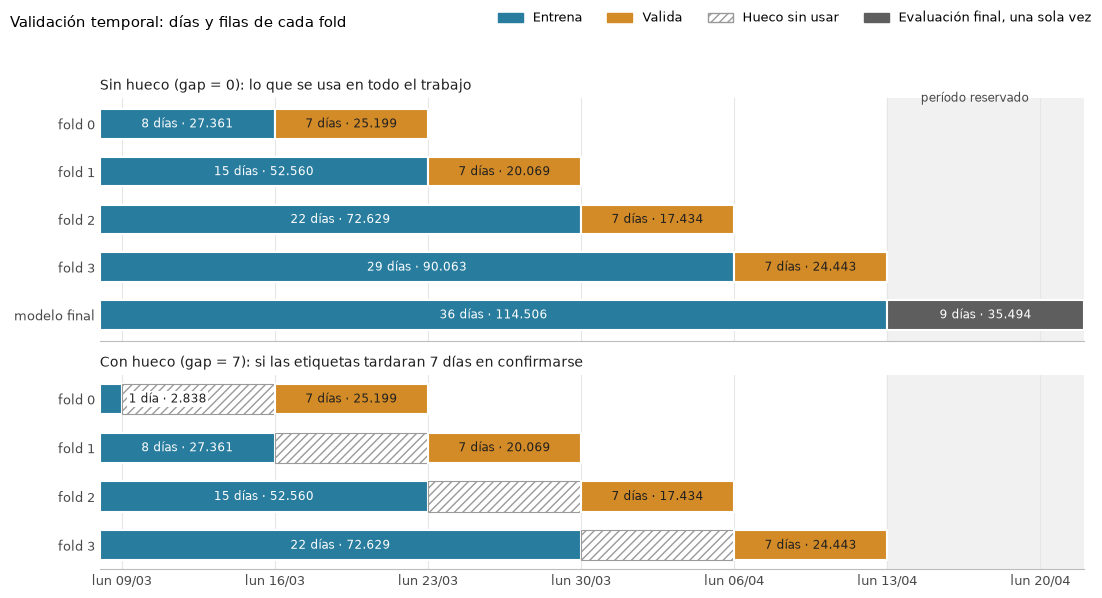

,entrena,dias_train,filas_train,valida,dias_valid,filas_valid
fold,,,,,,
fold 0,dom 08/03 – dom 15/03,8,27361,lun 16/03 – dom 22/03,7,25199
fold 1,dom 08/03 – dom 22/03,15,52560,lun 23/03 – dom 29/03,7,20069
fold 2,dom 08/03 – dom 29/03,22,72629,lun 30/03 – dom 05/04,7,17434
fold 3,dom 08/03 – dom 05/04,29,90063,lun 06/04 – dom 12/04,7,24443


In [5]:
comparacion = []
for bloques in (3, 4, 5):
    folds_prueba = list(temporal_folds(development.fecha, n_splits=bloques))
    primer_train, primer_valid = folds_prueba[0]
    comparacion.append(
        {
            "n_splits": bloques,
            "dias_por_bloque": development.fecha.iloc[primer_valid].dt.normalize().nunique(),
            "dias_train_fold_0": development.fecha.iloc[primer_train].dt.normalize().nunique(),
            "filas_train_fold_0": len(primer_train),
        }
    )
display(pd.DataFrame(comparacion).set_index("n_splits").round(2))

fig, calendario = plot_temporal_folds(development.fecha, test.fecha, gap_days=(0, 7))
plt.show()
display(calendario)

**Lectura: cuatro bloques es el único número que da semanas completas.**

Con 3 bloques cada validación dura 9 días y con 5, 6: ninguno es una semana. Con **4**, cada bloque es
exactamente una semana **de lunes a domingo**, del 16/03 al 12/04. De ahí `N_SPLITS = 4`.

Al leer resultados fold por fold, recordar la asimetría: **el fold 0 entrena con 8 días** y el fold 3
con 29.

El panel de abajo muestra qué hace el gap: las semanas de validación **no se mueven**, lo que se pierde es
entrenamiento. Con 7 días de hueco el fold 0 queda con un solo día.

**Decisión: `gap = 0`, de forma provisional.** La demora en producción no se puede medir con este
extracto: es una pregunta para el dueño del dato. Lo que sí se puede medir es cuánto costaría
equivocarse, y eso necesita un modelo: `03_modeling.ipynb` reentrena con huecos de hasta 7 días.

## 2. Calidad de datos

Con el período reservado ya apartado, revisamos qué tan completo está lo que vamos a usar y cuánto
costaría "limpiarlo" con los reflejos habituales.

In [6]:
quality = column_profile(development)
con_nulos = quality.loc[quality.nulos.gt(0)].copy()
# Si faltar se asocia con fraude, el indicador de faltante aporta; si no, solo completa la fila.
con_nulos["fraude_si_falta_pct"] = [
    100 * development.loc[development[columna].isna(), TARGET].mean() for columna in con_nulos.index
]
display(con_nulos.sort_values("nulos_pct", ascending=False).round(2))

print("Duplicados exactos:", development.duplicated().sum())
predictores = [col for col in development if col != TARGET]
repetidos = development.duplicated(subset=predictores, keep=False)
print(
    "Grupos de predictores idénticos con etiquetas distintas:",
    development.loc[repetidos].groupby(predictores, dropna=False)[TARGET].nunique().gt(1).sum(),
)

print()
print("Qué costaría eliminar toda fila con algún nulo:")
incompletas = development.isna().any(axis=1).rename("tiene_nulos")
display(
    rate_table(development, incompletas)[
        ["transacciones", "volumen_pct", "fraudes", "fraudes_pct"]
    ].round(2)
)

print("Qué costaría eliminar los extremos IQR de monto:")
limites = iqr_report(development, ["monto"]).loc["monto"]
extremos = (
    development.monto.lt(limites.limite_inferior) | development.monto.gt(limites.limite_superior)
).rename("monto_extremo")
display(
    rate_table(development, extremos)[
        ["transacciones", "volumen_pct", "fraudes", "fraudes_pct", "fraude_pct"]
    ].round(2)
)
print(f"f toma valores negativos en {development.f.lt(0).sum():,} filas. Fraude por tramo de f:")
display(
    rate_table(development, "f", bins=[-5, -1, 0, 1, 5, 20, np.inf])[
        ["transacciones", "fraude_pct"]
    ].round(2)
)

,tipo,nulos,nulos_pct,valores_distintos,fraude_si_falta_pct
o,str,83014,72.50,2,2.11
b,float64,12653,11.05,7286,6.14
c,float64,12653,11.05,100699,6.14
d,float64,332,0.29,51,8.43
m,float64,332,0.29,1742,8.43
g,str,117,0.10,44,6.84
f,float64,11,0.01,1214,0.00
l,float64,11,0.01,7180,0.00


Duplicados exactos: 0
Grupos de predictores idénticos con etiquetas distintas: 0

Qué costaría eliminar toda fila con algún nulo:


,transacciones,volumen_pct,fraudes,fraudes_pct
tiene_nulos,,,,
False,27855,24.33,3623,61.11
True,86651,75.67,2306,38.89


Qué costaría eliminar los extremos IQR de monto:


,transacciones,volumen_pct,fraudes,fraudes_pct,fraude_pct
monto_extremo,,,,,
False,103293,90.21,4936,83.25,4.78
True,11213,9.79,993,16.75,8.86


f toma valores negativos en 971 filas. Fraude por tramo de f:


,transacciones,fraude_pct
f,,
"(-5.001, -1.0]",971,9.47
"(-1.0, 0.0]",19119,11.94
"(0.0, 1.0]",9376,7.18
"(1.0, 5.0]",19511,5.27
"(5.0, 20.0]",26877,3.90
"(20.0, inf]",38641,2.08
Ausente,11,0.00


**Conclusión: no se elimina nada.** No hay duplicados exactos ni grupos de predictores idénticos con
etiquetas en conflicto. Y limpiar por reflejo saldría caro:

- `dropna()` descartaría el **75,7% de las transacciones y el 38,9% de los fraudes**.
- Recortar los montos extremos se llevaría el **16,75% de los fraudes**. Son extremos según la regla IQR,
  que marca lo que se aleja del 50% central de los montos más de una vez y media el ancho de ese 50%:
  11.213 transacciones, el 9,8%, con **8,86%** de fraude contra 4,78% del resto.

Donde el fraude es el 5% y los montos altos son los que más cuestan, las dos operaciones destruyen lo que
venimos a medir.

Los nulos se conservan: en las numéricas se imputa la mediana y se agrega un indicador de faltante, y las categóricas reciben una categoría de ausencia.
La columna `fraude_si_falta_pct` muestra que solo la ausencia de `o` cambia mucho el riesgo (2,11%):
donde faltan `b` y `c` (11,05% de las filas) el fraude es 6,14%, cerca del 5,18% de desarrollo. El
indicador se agrega igual, porque cuesta poco. Los negativos de `f` (971 filas) también se conservan: el
fraude más alto está en `f = 0` (11,94%), los negativos quedan cerca (9,47%) y desde ahí baja a medida
que `f` crece. No hay un salto en el signo que delate un error de carga: son parte de su rango.
Imputación, escalado y encoding se ajustan solo con el entrenamiento de cada fold.

## 3. Balance de clases y variables numéricas

Miramos el desbalance, la cardinalidad de las categóricas, la distribución del monto —la variable que
convierte tasas en dinero— y cuánto separa el fraude cada variable numérica.

,transacciones,porcentaje
fraude,,
No fraude,108577,94.82
Fraude,5929,5.18


,valores_distintos,nulos,nulos_pct
a,4,0,0.0
g,44,117,0.1
j,7770,0,0.0
o,2,83014,72.5
p,2,0,0.0


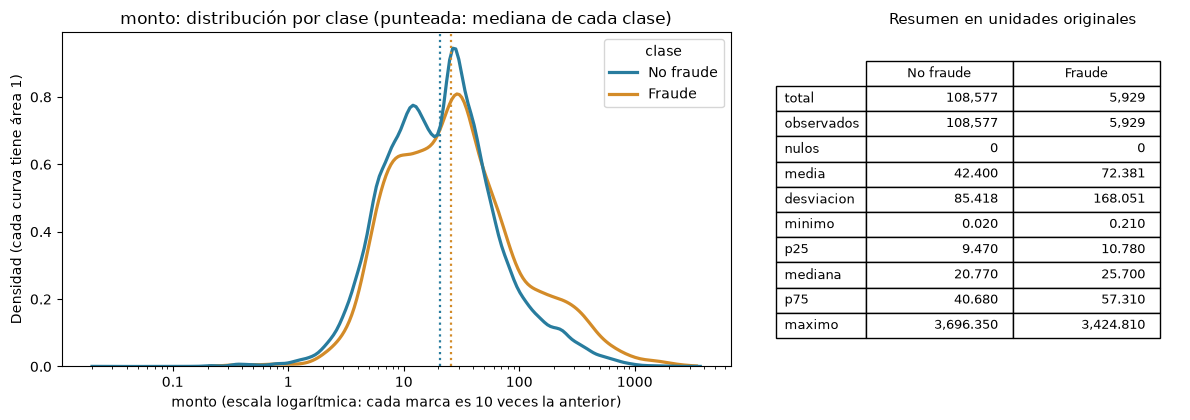

,No fraude,Fraude
total,108577.00,5929.00
observados,108577.00,5929.00
nulos,0.00,0.00
media,42.40,72.38
desviacion,85.42,168.05
minimo,0.02,0.21
p25,9.47,10.78
mediana,20.77,25.70
p75,40.68,57.31
maximo,3696.35,3424.81


Monto más alto de desarrollo: 3,696.35


In [7]:
target_summary = (
    development[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "No fraude", 1: "Fraude"})
    .to_frame("transacciones")
)
target_summary["porcentaje"] = 100 * target_summary.transacciones / len(development)
display(target_summary.round(2))

cardinalidad = column_profile(development, CATEGORICAL_COLUMNS)[
    ["valores_distintos", "nulos", "nulos_pct"]
]
display(cardinalidad.round(2))

fig, amount_summary = plot_class_distribution(development, "monto", log_scale=True)
plt.show()
display(amount_summary.round(2))
print(f"Monto más alto de desarrollo: {development[AMOUNT].max():,.2f}")

**Conclusión.** Fraude es el **5,18%** de desarrollo. En monto, la mediana pasa de **20,77** en no fraude
a **25,70** en fraude, y la media de **42,40** a **72,38**: el salto mucho mayor en la media es la cola
de montos altos, y es lo que hace que el problema se mida en dinero y no en transacciones.

El eje del gráfico está en escala logarítmica, para ver a la vez los montos de 1 y los de 1.000: cada
marca es 10 veces la anterior. Las curvas se superponen casi por completo, así que **el monto por sí
solo no separa**. La de fraude está apenas corrida a la derecha —las punteadas marcan las medianas— y
tiene más cola por encima de 100.

`j` tiene 7.770 valores distintos y `o` falta en el 72,5% de las filas. Son características a entender,
no motivos de exclusión: la sección 6 muestra que la ausencia de `o` es de los patrones que más
distinguen el fraude.

### ¿Y el resto de las numéricas?

El monto casi no separa el fraude. **Hipótesis:** otras numéricas separan más, y conviene saberlo antes
de decidir qué entra al modelo.

Para compararlas todas con la misma vara, en cada variable se ordenan las transacciones de menor a
mayor valor y se parten en cinco grupos del mismo tamaño: el 20% con los valores más bajos, el 20%
siguiente, y así hasta el 20% con los más altos. En cada grupo se mide el porcentaje de fraude. **Una
línea plana es una variable que no separa**; una que sube o baja, una que sí.

El número de cada título, `separacion`, lo resume: si se toma un fraude y una legítima al azar, es la
proporción de veces que la variable los distingue. **0,5 es tirar una moneda** —lo que da `k`, el
ruido— y 1 sería separar perfecto. Los nulos quedan afuera: tienen su propio indicador (§2).

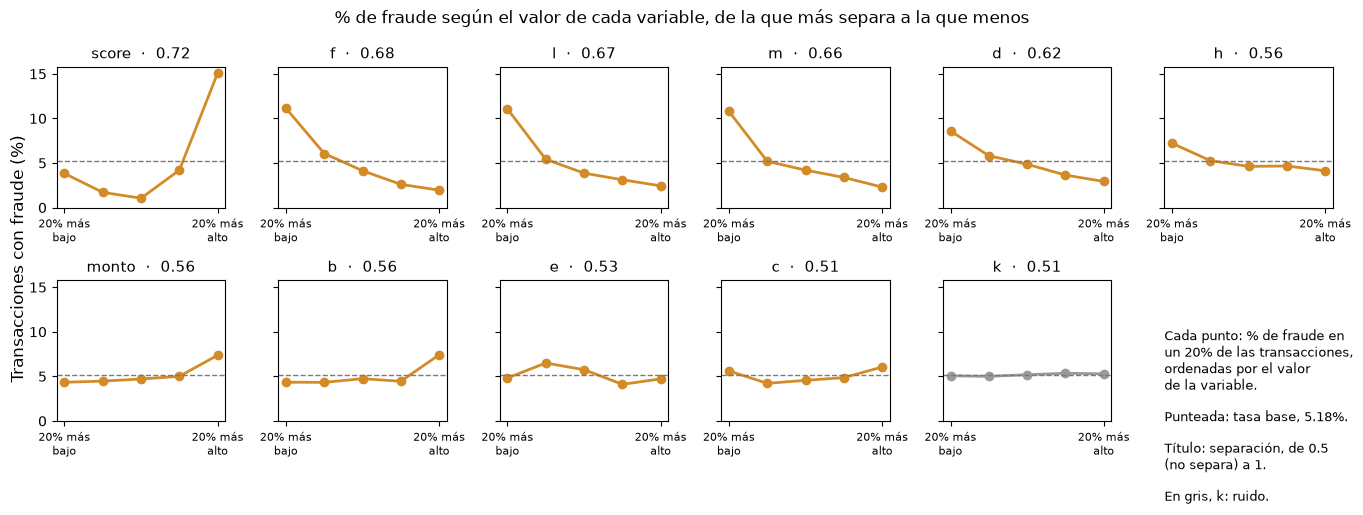

,separacion,sentido,20% más bajo,20–40%,40–60%,60–80%,20% más alto
score,0.723,"más valor, más fraude",3.83,1.71,1.05,4.20,15.11
f,0.684,"más valor, menos fraude",11.14,6.07,4.13,2.60,1.95
l,0.674,"más valor, menos fraude",11.06,5.42,3.86,3.12,2.44
m,0.661,"más valor, menos fraude",10.79,5.19,4.20,3.38,2.29
d,0.617,"más valor, menos fraude",8.59,5.82,4.86,3.65,2.93
h,0.561,"más valor, menos fraude",7.22,5.26,4.62,4.66,4.13
monto,0.560,"más valor, más fraude",4.34,4.47,4.70,5.01,7.38
b,0.559,"más valor, más fraude",4.34,4.33,4.74,4.45,7.43
e,0.531,"más valor, menos fraude",4.82,6.50,5.75,4.10,4.72
c,0.510,"más valor, más fraude",5.61,4.22,4.56,4.86,6.05


In [8]:
# separacion es el AUC invertido cuando a más valor hay menos fraude: siempre va de 0,5 a 1.
grupos = ["20% más bajo", "20–40%", "40–60%", "60–80%", "20% más alto"]
por_variable = {}
for columna in NUMERIC_COLUMNS:
    observadas = development.loc[development[columna].notna()]
    auc = roc_auc_score(observadas[TARGET], observadas[columna])
    grupo = pd.qcut(observadas[columna].rank(method="first"), 5, labels=grupos)
    por_variable[columna] = {
        "separacion": max(auc, 1 - auc),
        "sentido": "más valor, más fraude" if auc >= 0.5 else "más valor, menos fraude",
        **rate_table(observadas, grupo.rename("grupo"))["fraude_pct"].to_dict(),
    }
separacion_numericas = pd.DataFrame.from_dict(por_variable, orient="index").sort_values(
    "separacion", ascending=False
)

tasa_base = 100 * development[TARGET].mean()
fig, paneles = plt.subplots(2, 6, figsize=(14, 5.2), sharey=True)
for panel, (columna, fila) in zip(paneles.flat, separacion_numericas.iterrows()):
    color = "#9A9A9A" if columna in NOISE_COLUMNS else PALETTE["Fraude"]
    panel.plot(range(5), fila[grupos].astype(float), marker="o", color=color, linewidth=2)
    panel.axhline(tasa_base, color="#7A7A7A", linestyle="--", linewidth=1)
    panel.set_title(f"{columna}  ·  {fila.separacion:.2f}", fontsize=11)
    panel.set_xticks([0, 4], ["20% más\nbajo", "20% más\nalto"], fontsize=8)
paneles[0, 0].set_ylim(bottom=0)
fig.supylabel("Transacciones con fraude (%)")
paneles.flat[-1].axis("off")
paneles.flat[-1].text(
    0,
    0.5,
    "Cada punto: % de fraude en\nun 20% de las transacciones,\nordenadas por el valor\n"
    f"de la variable.\n\nPunteada: tasa base, {tasa_base:.2f}%.\n\n"
    "Título: separación, de 0.5\n(no separa) a 1.\n\nEn gris, k: ruido.",
    va="center",
    fontsize=9,
)
fig.suptitle("% de fraude según el valor de cada variable, de la que más separa a la que menos")
fig.tight_layout()
plt.show()
display(separacion_numericas.round({"separacion": 3} | {grupo: 2 for grupo in grupos}))

**Lectura: cuatro numéricas separan mucho más que el monto.** `f`, `l`, `m` y `d` tienen separación
entre 0,617 y 0,684, cerca de `score` (0,723), y las cuatro bajan: **a más valor, menos fraude**. En
`f`, el 20% con los valores más bajos tiene 11,14% de fraude, y el 20% más alto, 1,95%.

`monto` (0,560) y `b` (0,559) son casi planas: solo sube su 20% más alto, a 7,38% y 7,43%. `c`
(0,510) no se distingue de `k` (0,506), el ruido. El papel del monto no es separar el fraude: es
poner el precio de cada error. `score` tiene su punto más bajo en el medio y salta en su 20% más alto
(15,11%); la §5 lo analiza aparte.

Ninguna se descarta por separar poco: una variable que sola no separa puede aportar combinada con
otras.

## 4. La economía del problema

Hasta acá medimos fraude en tasas. El enunciado se define en dinero, así que traducimos sus dos reglas a
una función que se pueda optimizar.

**La función de ganancia.** Para una política que aprueba un conjunto A de transacciones:

```
ganancia(A) = 0.25 * suma de monto de las legítimas en A
                   - suma de monto de los fraudes en A
```

**La decisión, transacción por transacción.** Para una de monto `m` a la que el modelo le asigna
probabilidad `p` de ser fraude:

| Acción | Qué pasa | Valor esperado |
|---|---|---|
| Rechazar | nada | `0` |
| Aprobar | con probabilidad `1 - p` gano `0.25 * m`; con probabilidad `p` pierdo `m` | `0.25 * m * (1 - p) - m * p` |

**El despeje.** Conviene aprobar cuando aprobar vale más que rechazar:

```
0.25 * m * (1 - p) - m * p  >  0
m * [0.25 * (1 - p) - p]    >  0     <- m es factor común
    0.25 * (1 - p) - p      >  0     <- dividir por m, válido porque m > 0
    0.25 - 0.25p - p        >  0
                     0.25   >  1.25p
                        p   <  0.2
```

El paso clave es dividir por `m`, legítimo porque ya verificamos con un `assert` que todos los montos
son estrictamente positivos. Al dividir, **el monto desaparece de la desigualdad**.

**Qué significa.** El umbral óptimo es `p < 0,2` para toda transacción: la de 5 y la de 3.696 se deciden
con el mismo corte. Suena contraintuitivo, pero ganancia y pérdida escalan igual con el monto. Dicho
simple: **por cada fraude que dejo pasar necesito 4 transacciones legítimas del mismo monto para empatar**,
y de ahí sale 1/5 = 0,2.

Que el monto se cancele en el umbral **no significa que deje de importar**: equivocarse en una transacción
cara cuesta más, y por eso la sección 6 mide cada patrón en dinero y no solo en tasa. Si hubiera un costo
fijo por rechazo o por revisión manual, no escalaría con el monto y el umbral sí dependería de él; no es
el caso de este enunciado.

**Consecuencia para el modelado.** La decisión usa el **valor** de `p`, no solo el orden: importa que la
probabilidad sea fiel —si el modelo dice 0,2, que unas 2 de cada 10 sean fraude—, no solo que ordene bien.
`03_modeling.ipynb` §3 lo pone a prueba.

In [9]:
todas = approve_all(development)
politicas = {
    "Rechazar todo": ~todas,
    "Aprobar todo": todas,
    "Predicción perfecta": development[TARGET].eq(0),
}
display(gain_by_policy(development, politicas).round(2))

aprobar_todo = expected_gain(development, todas)
techo = max_gain(development)
print(f"Ganancia por legítima aprobada: {GAIN_RATE:.0%} del monto")
print(f"Umbral óptimo de probabilidad:  {optimal_probability_threshold():.2f}")
print(f"Monto total en desarrollo:      {development[AMOUNT].sum():,.0f}")
print(
    f"Monto en fraudes (exposición):  "
    f"{development.loc[development[TARGET].eq(1), AMOUNT].sum():,.0f}"
)
print(f"Brecha entre aprobar todo y predecir perfecto: {techo - aprobar_todo:,.0f}")

,ganancia,pct_del_maximo,aprobadas,aprobadas_pct,fraudes_aprobados
Rechazar todo,0.00,0.00,0.0,0.00,0.0
Aprobar todo,721774.18,62.71,114506.0,100.00,5929.0
Predicción perfecta,1150919.04,100.00,108577.0,94.82,0.0


Ganancia por legítima aprobada: 25% del monto
Umbral óptimo de probabilidad:  0.20
Monto total en desarrollo:      5,032,821
Monto en fraudes (exposición):  429,145
Brecha entre aprobar todo y predecir perfecto: 429,145


**Conclusión.** Aprobar todo deja **721.774** y una predicción perfecta daría **1.150.919**. La
diferencia, **429.145**, es el margen sobre el que compite cualquier modelo.

**No es "el dinero que hoy se pierde por fraude":** es la exposición bajo la política hipotética de
*aprobar todo*. El dataset no trae la decisión del sistema vigente, así que no sabemos cuánto de eso se
evita hoy. Y como toda suma de dinero, depende del primer supuesto: si `monto` mezclara monedas, este
total no sería válido hasta convertir a una unidad común.

## 5. `score`: la referencia que ya trae el dataset

`score` es un entero de 0 a 100 que viene con el dataset. El enunciado dice que los datos provienen "del
sistema de prevención de fraude de Mercado Libre", así que es plausible que sea la salida de ese sistema,
pero sin diccionario no lo damos por confirmado.

Si está asociado con la etiqueta, define la vara: un modelo que no lo supere no aporta nada. Antes de
usarlo hay que responder, en este orden: **¿es una fuga de información?** y, si no lo es, **¿cuánta
ganancia rinde?**

Primero, cuánto separa, con dos medidas que se usan en todo el trabajo:

- El **`lift`** de un tramo es cuántas veces la tasa de fraude promedio tiene ese tramo.
- El **AUC** es la probabilidad de que un fraude tomado al azar tenga un `score` más alto que una legítima
  tomada al azar: 0,5 es ordenar al azar y 1 es ordenar perfecto. Mide solo el orden, no el dinero.

,transacciones,volumen_pct,fraude_pct,lift,monto_en_fraude
score,,,,,
"(-0.001, 10.0]",13991,12.22,2.99,0.58,25422.03
"(10.0, 20.0]",11193,9.78,4.96,0.96,25975.04
"(20.0, 30.0]",10964,9.58,2.36,0.46,16226.47
"(30.0, 40.0]",11117,9.71,0.36,0.07,1731.69
"(40.0, 50.0]",11288,9.86,0.91,0.18,4591.80
"(50.0, 60.0]",11030,9.63,1.21,0.23,6919.53
"(60.0, 70.0]",11460,10.01,2.84,0.55,24104.27
"(70.0, 80.0]",11631,10.16,6.04,1.17,54111.73
"(80.0, 90.0]",12112,10.58,10.38,2.00,122333.66


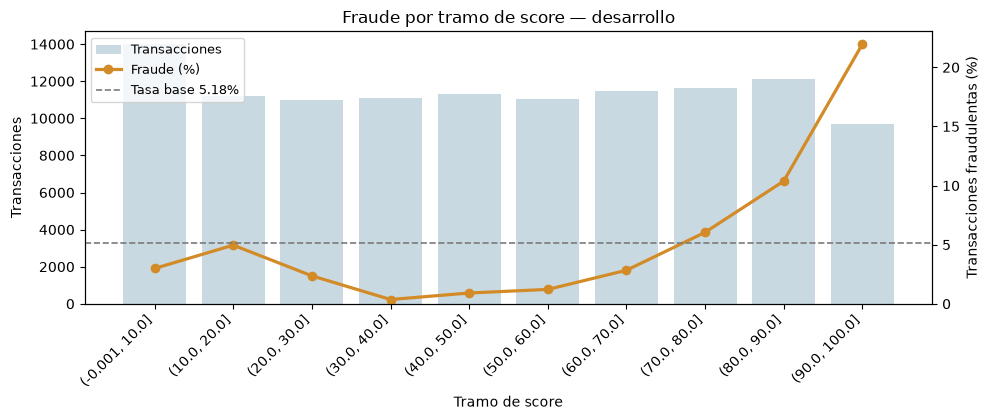

AUC de score solo:   0.7233
Tasa base de fraude: 0.0518


In [10]:
score_buckets = rate_table(development, "score", bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
display(
    score_buckets[["transacciones", "volumen_pct", "fraude_pct", "lift", "monto_en_fraude"]].round(
        2
    )
)
fig = plot_rate_table(
    score_buckets, title="Fraude por tramo de score — desarrollo", ylabel="Tramo de score"
)
plt.show()

print(f"AUC de score solo:   {roc_auc_score(development[TARGET], development.score):.4f}")
print(f"Tasa base de fraude: {development[TARGET].mean():.4f}")

### ¿`score` es una fuga de información?

Si `score` se calculara *después* de conocer el resultado de la transacción, sería inutilizable: el
modelo aprendería la respuesta y se caería en producción. No tenemos el diccionario de datos, pero sí
tres huellas que una variable filtrada dejaría y que se pueden medir.

In [11]:
semanal = development.assign(semana=development.fecha.dt.to_period("W-SUN").dt.start_time)
estabilidad = semanal.groupby("semana").apply(
    lambda g: pd.Series(
        {
            "transacciones": len(g),
            "fraude_pct": 100 * g[TARGET].mean(),
            "auc_score": roc_auc_score(g[TARGET], g.score),
            "score_mediano": g.score.median(),
        }
    ),
    include_groups=False,
)
display(estabilidad.round(3))

tope = development.loc[development.score.eq(100)]
print(f"score = 100 exacto: {len(tope):,} transacciones, {tope[TARGET].mean():.2%} de fraude")
print(
    f"Tramo 0-20:         {development.score.le(20).sum():,} transacciones, "
    f"{development.loc[development.score.le(20), TARGET].mean():.2%} de fraude"
)
print(
    f"AUC semanal: entre {estabilidad.auc_score.min():.4f} y "
    f"{estabilidad.auc_score.max():.4f} (desvío {estabilidad.auc_score.std():.4f})"
)

,transacciones,fraude_pct,auc_score,score_mediano
semana,,,,
2020-03-02,2838.0,4.369,0.764,53.0
2020-03-09,24523.0,4.828,0.718,52.0
2020-03-16,25199.0,4.560,0.716,53.0
2020-03-23,20069.0,5.690,0.732,52.0
2020-03-30,17434.0,5.782,0.733,45.0
2020-04-06,24443.0,5.409,0.725,44.0


score = 100 exacto: 1,617 transacciones, 29.50% de fraude
Tramo 0-20:         25,184 transacciones, 3.86% de fraude
AUC semanal: entre 0.7161 y 0.7637 (desvío 0.0174)


**Las tres huellas, y qué dicen.**

| Huella de una variable filtrada | Qué se observa | Lectura |
|---|---|---|
| El tramo más alto sería casi todo fraude | `score = 100` tiene **29,50%** de fraude | Lejos de ser la etiqueta disfrazada |
| El AUC sería cercano a 1 | **0,7233** sobre desarrollo | Útil, pero lejos de perfecto |
| La relación sería monótona y limpia | El tramo 0-20 tiene **3,86%**, muy por encima del piso de **0,36%** del tramo 30-40 | Una etiqueta filtrada difícilmente dejaría esa banda |

Además, el AUC semanal se mantiene entre **0,7161 y 0,7637** (desvío 0,0174): lejos de 1 en todas las
semanas, no solo en promedio.

**Conclusión: la evidencia es compatible con un puntaje calculado antes de decidir, no con una fuga.**
Es evidencia, no prueba, así que la pregunta sigue abierta para el dueño del dato. La decisión práctica
es la que no depende de la respuesta: **medir el modelo con y sin `score`** en `03_modeling.ipynb`.

La banda 0-20 queda como observación abierta: son 25.184 transacciones, así que no es ruido, y no le
inventamos explicación.

### ¿Cuánta ganancia rinde `score`?

La mejor regla de un solo corte es "aprobar si `score < t`". Pero elegir `t` sobre todo desarrollo y
después reportar la ganancia de ese mismo `t` sobre esos mismos datos da un número optimista: el corte
se ajustó a los datos con los que se lo mide. La vara honesta es temporal — **elegir el corte con el
pasado de cada fold y medirlo en su futuro** — que es exactamente la situación de producción.

In-sample: mejor corte 91 -> 757,218 (+35,444 sobre aprobar todo)


,corte_elegido,mejor_corte_posible,aprobar_todo,mejora_real,mejora_maxima
fold,,,,,
0,93,99,189217.43,-1126.63,2792.88
1,98,96,122877.61,1074.07,2142.47
2,95,86,85648.10,7211.78,20153.72
3,93,86,128268.77,16839.51,27515.08


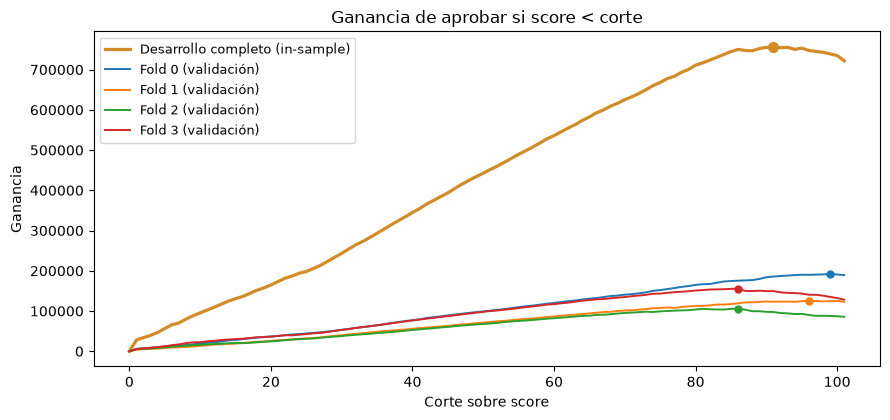

Mejora fuera de muestra, sumando los 4 folds: 23,999
Mejora si el corte se eligiera sobre la propia validación: 52,604
La regla captura el 45.6% de lo que daría elegir el corte mirando cada validación


In [12]:
cortes = range(102)
curva_total = sweep_gain(development, development.score, cortes)
print(
    f"In-sample: mejor corte {curva_total.idxmax()} -> {curva_total.max():,.0f} "
    f"({curva_total.max() - aprobar_todo:+,.0f} sobre aprobar todo)"
)

curvas = {"Desarrollo completo (in-sample)": curva_total}
filas = []
for numero, (train_pos, valid_pos) in enumerate(
    temporal_folds(development.fecha, n_splits=N_SPLITS)
):
    train, valid = development.iloc[train_pos], development.iloc[valid_pos]
    corte = sweep_gain(train, train.score, cortes).idxmax()  # elegido solo con el pasado
    curva_valid = sweep_gain(valid, valid.score, cortes)
    sin_regla = expected_gain(valid, approve_all(valid))
    curvas[f"Fold {numero} (validación)"] = curva_valid
    filas.append(
        {
            "corte_elegido": corte,
            "mejor_corte_posible": curva_valid.idxmax(),
            "aprobar_todo": sin_regla,
            "mejora_real": expected_gain(valid, valid.score.lt(corte)) - sin_regla,
            "mejora_maxima": curva_valid.max() - sin_regla,
        }
    )
folds = pd.DataFrame(filas)
folds.index.name = "fold"
display(folds.round(2))

fig = plot_gain_curve(
    curvas, title="Ganancia de aprobar si score < corte", xlabel="Corte sobre score"
)
plt.show()

print(f"Mejora fuera de muestra, sumando los 4 folds: {folds.mejora_real.sum():,.0f}")
print(
    f"Mejora si el corte se eligiera sobre la propia validación: "
    f"{folds.mejora_maxima.sum():,.0f}"
)
print(
    f"La regla captura el {100 * folds.mejora_real.sum() / folds.mejora_maxima.sum():.1f}% "
    f"de lo que daría elegir el corte mirando cada validación"
)

**Conclusión: la vara real es bastante más baja de lo que parece.**

Sobre todo desarrollo, el mejor corte es `score < 91` y rinde **+35.444** sobre aprobar todo. Ese
número es in-sample y no se puede usar como objetivo. Medido como en producción, el corte que elige cada
fold cambia —**93, 98, 95 y 93**— y la mejora sumada sobre las cuatro validaciones es **+23.999**: el
**45,6%** de los +52.604 que daría elegir el corte mirando cada validación.

Hay un resultado que conviene no esconder: **en el fold 0 la regla pierde dinero, −1.127**. Es el fold
que entrena con 8 días, y el corte que aprendió ahí, 93, no se sostiene en su validación, donde el mejor
habría sido 99.

**La vara para `03_modeling.ipynb`:** superar una mejora de unos **24.000** medida fuera de muestra.
Sobre una brecha disponible de 429.145, ni siquiera el número optimista llega al 10%: hay muchísimo
margen para un modelo.

## 6. Qué variables separan, y cuánto valen

Acá la economía cambia el análisis. Un segmento con riesgo alto y poco monto puede no valer nada, y uno
con riesgo moderado y mucho volumen puede costar una fortuna si se lo rechaza.

Por eso cada segmento candidato se mide con **cuatro preguntas**: cuánta gente toca (`transacciones`),
cuán riesgoso es (`fraude_pct`, `lift`), cuánto dinero hay expuesto (`monto_en_fraude`) y —la que
decide— **cuánto cambiaría la ganancia si se rechazara el segmento entero** frente a aprobar todo.

Es una tabla descriptiva sobre datos con etiqueta conocida: sirve para saber dónde mirar, no para fijar
reglas de producción.

In [13]:
hora = development.fecha.dt.hour
apariciones_j = development.j.map(development.j.value_counts())
segmentos = {
    "o = N": development.o.eq("N"),
    "o = N y n = 0": development.o.eq("N") & development.n.eq(0),
    "n = 0": development.n.eq(0),
    "score >= 90": development.score.ge(90),
    "hora entre 0 y 5": hora.lt(6),
    "a en {1, 3}": development.a.isin([1, 3]),
    "j con más de 500 apariciones": apariciones_j.gt(500),
    "h = 0": development.h.eq(0),
    "p = N": development.p.eq("N"),
    "o ausente": development.o.isna(),
}

filas = []
for nombre, mascara in segmentos.items():
    mascara = mascara.fillna(False)
    grupo = development.loc[mascara]
    monto_total = grupo[AMOUNT].sum()
    en_fraude = grupo.loc[grupo[TARGET].eq(1), AMOUNT].sum()
    filas.append(
        {
            "segmento": nombre,
            "transacciones": int(mascara.sum()),
            "volumen_pct": 100 * mascara.mean(),
            "fraude_pct": 100 * grupo[TARGET].mean(),
            "lift": grupo[TARGET].mean() / development[TARGET].mean(),
            "monto_en_fraude": en_fraude,
            "pct_del_monto_en_fraude": 100 * en_fraude / monto_total,
            "ganancia_si_se_rechaza": expected_gain(development, ~mascara) - aprobar_todo,
        }
    )
ranking_segmentos = (
    pd.DataFrame(filas).set_index("segmento").sort_values("ganancia_si_se_rechaza", ascending=False)
)
display(ranking_segmentos.round(2))

umbral = 100 * optimal_probability_threshold()
print(f"Umbral de rentabilidad: rechazar conviene si pct_del_monto_en_fraude > {umbral:.0f}%")
print(
    "¿El signo de la ganancia coincide con esa regla en los",
    len(ranking_segmentos),
    "segmentos?",
    bool(
        (
            ranking_segmentos.pct_del_monto_en_fraude.gt(umbral)
            == ranking_segmentos.ganancia_si_se_rechaza.gt(0)
        ).all()
    ),
)

mejor_regla_score = curva_total.max() - aprobar_todo
print(
    f"Rechazar o = N rinde "
    f"{ranking_segmentos.loc['o = N', 'ganancia_si_se_rechaza'] / mejor_regla_score:.1f} veces "
    f"la mejor regla sobre score, las dos medidas sobre todo desarrollo"
)

,transacciones,volumen_pct,fraude_pct,lift,monto_en_fraude,pct_del_monto_en_fraude,ganancia_si_se_rechaza
segmento,,,,,,,
o = N,12969,11.33,22.74,4.39,222995.69,32.97,109636.61
o = N y n = 0,3529,3.08,36.95,7.14,93792.58,51.17,71412.47
n = 0,11005,9.61,16.80,3.24,135188.71,27.06,44102.33
score >= 90,10922,9.54,21.18,4.09,160501.59,23.99,33368.67
hora entre 0 y 5,4340,3.79,11.59,2.24,41040.30,22.69,6073.15
"a en {1, 3}",5474,4.78,9.06,1.75,60238.41,12.42,-45959.17
j con más de 500 apariciones,14539,12.70,6.79,1.31,109934.06,14.57,-51201.39
h = 0,9784,8.54,9.57,1.85,79686.57,12.81,-55891.35
p = N,50779,44.35,7.92,1.53,291394.73,12.66,-211313.12


Umbral de rentabilidad: rechazar conviene si pct_del_monto_en_fraude > 20%
¿El signo de la ganancia coincide con esa regla en los 10 segmentos? True
Rechazar o = N rinde 3.1 veces la mejor regla sobre score, las dos medidas sobre todo desarrollo


**El umbral 0,2 reaparece, ahora por segmento.** Rechazar un segmento conviene **exactamente cuando más
del 20% de su monto está en fraude**, y el signo coincide en los diez casos: es el mismo `p < 0,2` de la
sección 4, aplicado a un grupo. Lo que importa es **la parte del monto que es fraude**, no la del conteo.
Por eso `n = 0` conviene rechazarlo con 16,80% de fraude en transacciones —sus fraudes son caros y llegan
al 27,06% del monto— mientras que `h = 0`, con 9,57%, no.

In [14]:
# Lo que se midió y no dio: reportarlo acota el trabajo de la etapa siguiente.
tiempo = development.assign(
    dia_semana=development.fecha.dt.dayofweek, finde=development.fecha.dt.dayofweek.ge(5)
)
print(
    f"k — AUC: {roc_auc_score(development[TARGET], development.k):.4f} | "
    f"Spearman con el orden temporal: "
    f"{development.k.corr(development.fecha.astype('int64'), method='spearman'):.4f}"
)
print(
    f"j — {development.j.nunique():,} valores distintos, "
    f"{development.groupby('j').g.nunique().mean():.2f} países por valor en promedio"
)
display(
    rate_table(
        development, apariciones_j.rename("apariciones_de_j"), bins=[0, 1, 5, 20, 100, 500, 2000]
    )[["transacciones", "fraude_pct", "lift"]].round(2)
)
negativas = pd.concat(
    [
        rate_table(tiempo, "dia_semana")[["transacciones", "fraude_pct", "lift"]],
        rate_table(tiempo, "finde")[["transacciones", "fraude_pct", "lift"]],
    ]
)
display(negativas.round(2))

# a viene codificada 1 a 4: si su riesgo no sigue ese orden, no puede entrar como número.
print("Fraude por valor de a:")
display(rate_table(development, "a")[["transacciones", "volumen_pct", "fraude_pct"]].round(2))

k — AUC: 0.5061 | Spearman con el orden temporal: 0.0035
j — 7,770 valores distintos, 1.26 países por valor en promedio


,transacciones,fraude_pct,lift
apariciones_de_j,,,
"(-0.001, 1.0]",2302,3.21,0.62
"(1.0, 5.0]",7743,3.25,0.63
"(5.0, 20.0]",19131,3.94,0.76
"(20.0, 100.0]",38568,5.13,0.99
"(100.0, 500.0]",32223,5.85,1.13
"(500.0, 2000.0]",14539,6.79,1.31


,transacciones,fraude_pct,lift
0,18342,4.97,0.96
1,17794,5.42,1.05
2,17698,5.11,0.99
3,17232,5.45,1.05
4,14665,5.31,1.02
5,12836,5.02,0.97
6,15939,4.93,0.95
False,85731,5.25,1.01
True,28775,4.97,0.96


Fraude por valor de a:


,transacciones,volumen_pct,fraude_pct
a,,,
1,3218,2.81,9.01
2,11463,10.01,7.81
3,2256,1.97,9.13
4,97569,85.21,4.65


**Qué patrones distinguen el fraude, en orden de lo que rinden.**

**`o`: su ausencia informa.** Falta en el 72,5% de las filas, y ese grupo tiene apenas **2,11%** de
fraude, mientras que `o = N` llega al **22,74%**. Rechazar `o = N` rinde **+109.637**, más de tres veces
la mejor regla sobre `score`, y cruzarla con `n = 0` concentra **36,95%** de fraude en el 3,08% del
volumen. Consecuencia para el modelado: **el indicador de nulo tiene que ser una feature explícita**, no
un valor a imputar y olvidar.

**El `lift` por sí solo engaña.** `p = N` tiene lift 1,53 y rechazarlo cuesta **−211.313**, porque toca
el 44,35% del volumen. `h = 0` tiene lift 1,85 y cuesta −55.891. En cambio `hora entre 0 y 5` tiene lift
2,24 y rinde apenas +6.073, porque es el 3,79% del volumen: un patrón real, pero chico. `a` se trata como
**categórica nominal**: su tasa de fraude no sigue el orden 1-4 (9,01%, 7,81%, 9,13% y 4,65%), y por eso
el segmento de la tabla es `{1, 3}`.

**Lo que se midió y no dio.** Día de semana (4,93% a 5,45%) y fin de semana (5,25% contra 4,97%) no
separan por sí solos, así que no se construyen features de calendario. `k` es ruido: AUC **0,5061** y sin
relación con la fecha (correlación 0,0035). Se conserva como **vara**: al leer importancias, una feature que
puntúe por debajo de `k` compite con ruido.

`j` tiene 7.770 valores, **1,26 países distintos por valor**, y su riesgo crece con la frecuencia (3,21% en
los que aparecen una vez, 6,79% en los de más de 500). Se comporta como una categoría de segmento, no como
un identificador de usuario: **no hay perfil por usuario construible con estos datos**. `j` y `g` necesitan
un encoding calculado solo con el pasado de cada fold (`02_feature_engineering.ipynb`); hacerlo sobre todo
el dataset sería fuga.

### ¿Qué puede ser `o`?

No le vamos a inventar un nombre de negocio, pero **su estructura sí se puede medir**. Hasta acá la miramos
partida en dos, ausente contra `o = N`. Faltan tres cosas: **dónde queda `o = Y`**, si la ausencia cambia
con el tiempo, y cómo se relaciona con `n`.

**Hipótesis.** Si `o` fuera un dato opcional que el comprador aporta o no, la ausencia debería ser *más*
riesgosa: la falta de información suele ser mal indicio. Si en cambio fuera el resultado de una
verificación que **solo corre para algunas transacciones**, la ausencia debería ser la más segura, porque
a esas transacciones no les hizo falta verificar.

In [15]:
estado_o = development.o.fillna("ausente")
display(
    pd.DataFrame(
        {
            "transacciones": estado_o.value_counts(),
            "volumen_pct": 100 * estado_o.value_counts(normalize=True),
            "fraude_pct": 100 * development.groupby(estado_o)[TARGET].mean(),
            "monto_mediano": development.groupby(estado_o)[AMOUNT].median(),
        }
    ).round(2)
)

print("Cómo se reparte o dentro de cada valor de n (%):")
display(pd.crosstab(development.n, estado_o, normalize="index").mul(100).round(1))
print("Fraude por combinación de o y n (%):")
display((100 * development.groupby([estado_o, development.n])[TARGET].mean()).round(2))

semana = development.fecha.dt.to_period("W-SUN").dt.start_time
print(
    "Ausencia de o por semana (%):",
    ", ".join(f"{valor:.1f}" for valor in 100 * development.o.isna().groupby(semana).mean()),
)

,transacciones,volumen_pct,fraude_pct,monto_mediano
o,,,,
N,12969,11.33,22.74,23.45
Y,18523,16.18,6.62,20.20
ausente,83014,72.50,2.11,20.86


Cómo se reparte o dentro de cada valor de n (%):


o,N,Y,ausente
n,,,
0,32.1,0.3,67.6
1,9.1,17.9,73.0


Fraude por combinación de o y n (%):


o        n
N        0    36.95
         1    17.43
Y        0    15.62
         1     6.61
ausente  0     7.25
         1     1.61
Name: fraude, dtype: float64

Ausencia de o por semana (%): 71.5, 72.7, 72.6, 72.5, 72.0, 72.6


**Lectura: la ausencia es el grupo más seguro, así que los datos no apoyan la primera hipótesis.**

Las tres categorías se ordenan **ausente (2,11%) < `Y` (6,62%) < `N` (22,74%)**. Un campo opcional se
habría comportado al revés. Lo que sí es compatible es que **`o` sea el resultado de una verificación que
solo corre para una parte de las transacciones**: la ausencia diría "acá no hizo falta revisar", y dentro
de lo verificado, `N` es el resultado malo.

Dos mediciones más van en esa línea. **La ausencia es estable**: entre 71,5% y 72,7% en las seis semanas.
Y **depende mucho de `n`**: con `n = 0`, `o` vale `Y` en apenas el 0,3% de los casos y `N` en el 32,1%;
con `n = 1`, 17,9% y 9,1%.

**Por qué importa.** Si es así, la variable más valiosa del dataset **describe una decisión que el sistema
anterior ya tomó**, no la transacción:

- Tiene la misma pregunta pendiente que `score`: **¿en qué momento se calcula?** Si fuera después de
  conocer el resultado, sería fuga.
- Si cambia la regla que decide cuándo se verifica, la variable cambia de significado sin que nada falle.
- Si este modelo reemplazara al sistema que dispara la verificación, el campo podría dejar de completarse
  y todo pasaría a "ausente", que el modelo aprendió a leer como seguro.

**Es la primera pregunta para el dueño del dato**: qué es `o`, cuándo se completa y qué decide que se
complete.

## 7. Correlaciones entre predictores

La matriz usa **Spearman**, que compara el orden de los valores: mide si una variable tiende a crecer
cuando la otra crece, siga o no una recta. Estas variables tienen colas largas, y **Pearson**, que usa las
magnitudes originales, puede cambiar por completo por un solo extremo; se agrega solo para tres pares,
para ver cuánto cambia la lectura.

Es una vista de dependencias de a pares, no de efectos ajustados, y no demuestra causalidad.

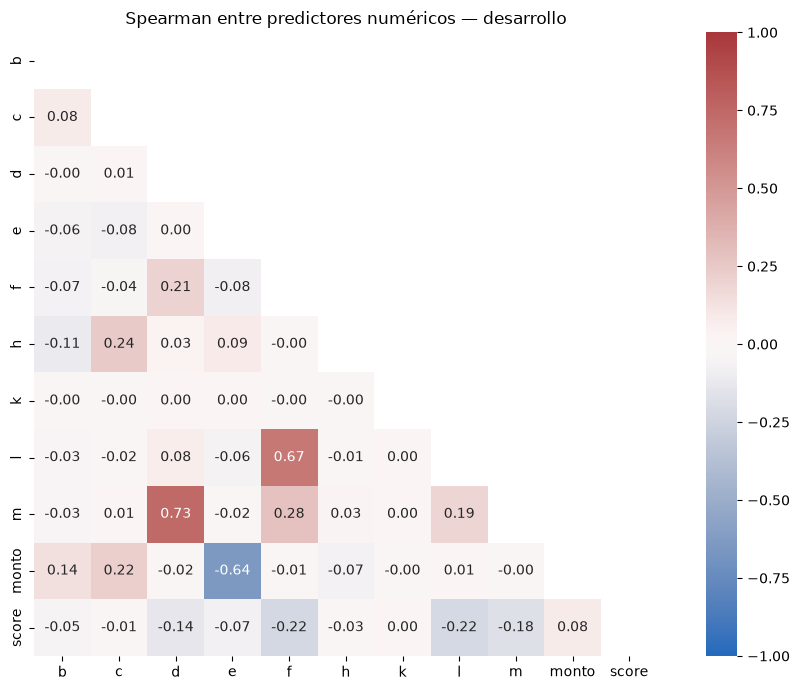

,n_observados,Spearman,Pearson
par,,,
d / m,114174,0.735,0.592
f / l,114495,0.667,0.076
e / monto,114506,-0.644,-0.059


In [16]:
spearman = development[numeric_columns].corr(method="spearman")
pearson = development[numeric_columns].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones(spearman.shape, dtype=bool))
sns.heatmap(
    spearman,
    mask=mask,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    square=True,
    ax=ax,
)
ax.set_title("Spearman entre predictores numéricos — desarrollo")
fig.tight_layout()
plt.show()

comparison = pd.DataFrame(
    [
        {
            "par": f"{first} / {second}",
            "n_observados": len(development[[first, second]].dropna()),
            "Spearman": spearman.loc[first, second],
            "Pearson": pearson.loc[first, second],
        }
        for first, second in [("d", "m"), ("f", "l"), ("e", "monto")]
    ]
).set_index("par")
display(comparison.round(3))

**Conclusión.** `d / m` se asocian con los dos métodos (**0,735** y **0,592**). Los otros dos pares
muestran por qué elegir la medida importa: en `f / l`, Spearman da **0,667** y Pearson **0,076**; en
`e / monto`, **−0,644** contra **−0,059**. Hay una relación monótona fuerte que la escala original no
refleja como recta. La discrepancia sugiere revisar forma y extremos, pero no prueba por sí sola que los
outliers sean la causa.

Dos de esos pares, `d / m` y `f / l`, son justo las numéricas que más separan el fraude en la §3:
parte de lo que separa cada una puede ser lo mismo.

**No eliminamos ninguna variable por correlación.** Los modelos de árbol toleran predictores
correlacionados, y con 11 numéricas el costo de conservarlas es bajo frente al riesgo de descartar un
patrón de fraude.

## 8. País y tiempo

Dos preguntas de estabilidad: ¿el fraude se comporta igual entre países?, y ¿es estable semana a semana?

Se muestran los cuatro países con más transacciones y el resto se agrupa solo para esta tabla; **Otros**
es heterogéneo y no se lee como un país.

In [17]:
country_counts = development.g.value_counts()
main_countries = country_counts.head(4).index
country_labels = development.g.where(development.g.isin(main_countries), "Otros")
country_labels = country_labels.mask(development.g.isna(), "Ausente")
country_data = development.assign(pais=country_labels)

country_summary = summarize_segments(country_data, ["pais"])
country_summary["volumen_pct"] = 100 * country_summary.transacciones / len(development)
country_summary["o_ausente_pct"] = country_data.groupby("pais").o.apply(
    lambda values: values.isna().mean() * 100
)
display(
    country_summary[
        ["transacciones", "volumen_pct", "fraudes", "fraude_pct", "monto_mediano", "o_ausente_pct"]
    ]
    .sort_values("transacciones", ascending=False)
    .round(2)
)

,transacciones,volumen_pct,fraudes,fraude_pct,monto_mediano,o_ausente_pct
pais,,,,,,
BR,86441,75.49,4880,5.65,19.00,72.29
AR,23377,20.42,934,4.00,29.22,72.93
UY,2244,1.96,27,1.20,23.53,75.31
US,1608,1.40,46,2.86,23.74,73.57
Otros,719,0.63,34,4.73,17.76,71.63
Ausente,117,0.10,8,6.84,16.89,74.36


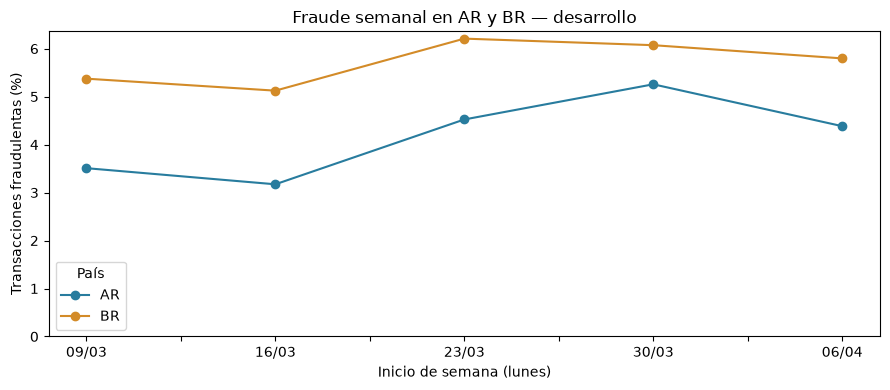

transacciones  fraudes  fraude_pct
semana     g                                     
2020-03-09 AR           5757      202        3.51
           BR          17843      959        5.37
2020-03-16 AR           5768      183        3.17
           BR          18460      946        5.12
2020-03-23 AR           4023      182        4.52
           BR          15251      947        6.21
2020-03-30 AR           2644      139        5.26
           BR          14014      851        6.07
2020-04-06 AR           4630      203        4.38
           BR          18681     1083        5.80

In [18]:
# Semanas lunes a domingo. Las semanas incompletas se excluyen solo de este gráfico.
weekly_data = development.loc[development.g.isin(["AR", "BR"])].copy()
weekly_data["semana"] = weekly_data.fecha.dt.to_period("W-SUN").dt.start_time
weekly_summary = summarize_segments(weekly_data, ["semana", "g"])
first_day = development.fecha.min().normalize()
last_day = development.fecha.max().normalize()
week_start = weekly_summary.index.get_level_values("semana")
weekly_summary = weekly_summary.loc[
    (week_start >= first_day) & (week_start + pd.Timedelta(days=6) <= last_day)
]
weekly_rates = weekly_summary.fraude_pct.unstack("g")
weekly_rates.index = weekly_rates.index.strftime("%d/%m")

fig, ax = plt.subplots(figsize=(9, 4))
weekly_rates.plot(ax=ax, marker="o", color=["#287C9E", "#D38B28"])
ax.set(
    title="Fraude semanal en AR y BR — desarrollo",
    xlabel="Inicio de semana (lunes)",
    ylabel="Transacciones fraudulentas (%)",
    ylim=(0, None),
)
ax.legend(title="País")
fig.tight_layout()
plt.show()
display(weekly_summary[["transacciones", "fraudes", "fraude_pct"]].round(2))

**Conclusión.** BR concentra el **75,5%** del volumen con **5,65%** de fraude y AR el 20,4% con
**4,00%**. UY y US tienen tasas más bajas (1,20% y 2,86%) pero solo **27 y 46 fraudes**: con ese soporte,
la diferencia no es interpretable. El resultado global está dominado por BR, así que conviene reportar
desempeño global **y** por país, aunque eso todavía no justifica modelos separados. Las medianas de monto son del mismo orden en los cuatro países —19,00 en BR, 29,22 en AR, 23,53 en UY
y 23,74 en US—: si cada país estuviera en su moneda, pesos y reales darían montos de órdenes muy
distintos. Es **compatible con una moneda común**, aunque sin diccionario no se confirma.

En el tiempo, las tasas semanales de AR y BR se mueven en una banda estrecha —AR entre 3,17% y 5,26%, BR
entre 5,12% y 6,21%— sin saltos ni tendencia marcada, y BR está por encima de AR en todas las semanas.
**Dentro de desarrollo no hay un cambio de régimen**, así que las semanas de validación son comparables
entre sí. Lo que pasa después del 13 de abril no se ve acá: la baja del período reservado sigue sin
explicación (sección 1). Cada punto es una tasa semanal y los volúmenes son distintos: leer la tabla junto
al gráfico.

## 9. Conclusiones para la siguiente etapa

- **La vara, medida fuera de muestra.** Aprobar todo rinde **721.774** sobre desarrollo y una predicción
  perfecta daría **1.150.919**: hay **429.145** en disputa. La mejor regla de un corte sobre `score`
  mejora **+23.999** medida como en producción. Ese es el número a superar.
- **El umbral es 0,2 y no depende del monto.** Por eso la probabilidad del modelo tiene que ser fiel, no
  solo ordenar bien. En segmentos se aplica igual, sobre la parte del monto que es fraude.
- **Dónde está el valor.** `o` es lo más fuerte del dataset y su ausencia informa: el indicador de nulo
  tiene que ser una feature explícita. Entre las numéricas, `f`, `l`, `m` y `d` separan casi como
  `score`: a más valor, menos fraude. `n`, `score` y la madrugada aportan; `p`, `h` y `a` tienen lift
  mayor a 1 pero rechazarlos destruye valor.
- **Sin perfil por usuario, con encoding temporal.** No hay identificador utilizable; `j` y `g` necesitan
  encoding calculado solo con el pasado de cada fold, y `k` queda como vara de ruido.
- **Un modelo global, evaluado también por país.** BR domina el volumen; si eso deja peor servida a AR es
  una hipótesis para el modelado, no un resultado de acá.

### Los supuestos, al cierre

| Supuesto | Resultado |
|---|---|
| `monto` en unidad monetaria común | **Compatible, sin confirmar.** Las medianas por país son del mismo orden (§8); confirmarlo requiere el diccionario de datos. Si mezcla monedas, las sumas de dinero deben recalcularse sobre una unidad común |
| `g` es el país | **Abierto.** Los códigos lo sugieren; las conclusiones por país son hipótesis |
| `score` disponible al decidir | **Evaluado: compatible con un puntaje previo a la decisión**, no con una fuga. Igual se mide el modelo con y sin `score` |
| Etiquetas sin demora relevante | **En parte.** Las del extracto no muestran truncamiento. La demora en producción no se puede medir acá: `gap = 0` es provisional, y su costo se mide en `03_modeling.ipynb` |

In [19]:
assert len(clean) == len(df)
pd.testing.assert_series_equal(clean.monto, df.monto)
print("Verificado: filas y montos originales conservados.")

Verificado: filas y montos originales conservados.
